In [3]:
import pandas as pd
df = pd.read_csv("../data/raw/homenest_reviews.csv")
import sys
import os
sys.path.append("..")

In [4]:
df_sample = df.sample(20, random_state=42).reset_index(drop=True)

In [5]:
from src.llm_tasks import batch_sentiment

sentiments = batch_sentiment(df_sample)


c:\Stellantis\HomeNestReviews_llm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Stellantis\HomeNestReviews_llm\notebooks\..\src\llm_client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
  5%|▌         | 1/20 [00:04<01:25,  4.52s/it]


KeyboardInterrupt: 

In [20]:
import os 
os.makedirs("../data/processed", exist_ok=True)

In [21]:
sentiments.to_csv("../data/processed/llm_sentiment.csv",index=False)

LLM Sentiment Analysis Done

Output : processed/llm_sentiment.csv

Evaluation : LLM Sentiment VS BERT Sentiment vs Ground Truth

In [22]:
import pandas as pd
from sklearn.metrics import classification_report

In [26]:
df_ground = pd.read_csv("../data/raw/homenest_reviews.csv")[["review_id","star_rating"]]
df_bert = pd.read_csv("../data/raw/homenest_reviews.csv")
df_llm = pd.read_csv("../data/processed/llm_sentiment.csv")

In [30]:
df_ground.columns
df_bert.columns

Index(['review_id', 'product_category', 'product_name', 'review_text',
       'star_rating', 'review_date', 'verified_purchase'],
      dtype='str')

Text Summarization using LLM

In [6]:
from src.llm_tasks import batch_summarize
import pandas as pd

#df_sample = df.sample(20, random_state=42).reset_index(drop=True)



In [7]:
df_sample = pd.read_csv("../data/raw/sample_to_be_summarized_data.csv")

In [8]:
df_sample


,review_id,review_text
0,1,I purchased this coffee maker about a month ag...
1,2,This LED vanity mirror looked very stylish whe...
2,3,I bought this blender mainly to make smoothies...
3,4,This desk lamp has a modern design and fits we...
4,5,The electric kettle boils water extremely fast...
5,6,I ordered this office chair because I spend lo...
6,7,These wireless headphones have surprisingly go...
7,8,I decided to try this air fryer after reading ...
8,9,This smartwatch has a bright display that is e...
9,10,I bought this phone case to protect my new sma...


In [10]:
summaries_llm = batch_summarize(df_sample)

100%|██████████| 20/20 [00:46<00:00,  2.34s/it]


In [14]:
summaries_llm = summaries_llm.merge(
    df_sample[["review_text"]],
    left_on="review_id",
    right_index=True
)

In [15]:
summaries_llm.to_csv("../data/processed/llm_summaries.csv", index=False)

LLM Entity Extraction + Clustering --> There's no Equivalent in Classical NLP , it's beyonf BERT or SpaCy

In [16]:
from src.llm_tasks import batch_extract_entities


In [22]:
df_reviews_for_entities = pd.read_csv("../data/raw/homenest_reviews.csv")
df_reviews_for_entities = (
    df_reviews_for_entities.sample(n=200, random_state=42).reset_index(drop=True)
)

In [23]:
df_entities = batch_extract_entities(df_reviews_for_entities)

100%|██████████| 200/200 [18:47<00:00,  5.64s/it] 


In [24]:
df_entities.to_csv(
    "../data/processed/llm_entities.csv",
    index=False
)

In [25]:
import ast

df_entities["problems"] = df_entities["problems"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [26]:
all_problems = []

for _, row in df_entities.iterrows():

    problems = row.get("problems", [])

    for p in problems:
        all_problems.append({
            "review_id": row["review_id"],
            "problem": p
        })

df_problems = pd.DataFrame(all_problems)

df_problems.head()

,review_id,problem
0,107,arrived damaged
1,107,smells like chemicals
2,1601,arrived damaged
3,1601,smells like chemicals
4,2465,Delivery took 3 weeks


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=200)

X = vec.fit_transform(df_problems["problem"])

In [28]:
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df_problems["cluster"] = km.fit_predict(X)

df_problems.head()

,review_id,problem,cluster
0,107,arrived damaged,0
1,107,smells like chemicals,0
2,1601,arrived damaged,0
3,1601,smells like chemicals,0
4,2465,Delivery took 3 weeks,0


In [29]:
order_centroids = km.cluster_centers_.argsort()[:, ::-1]

terms = vec.get_feature_names_out()

for i in range(6):

    top = [terms[j] for j in order_centroids[i, :5]]

    print(f"Cluster {i}: {top}")

Cluster 0: ['smells', 'like', 'damaged', 'arrived', 'stopped']
Cluster 1: ['waste', 'of', 'money', 'working', 'within']
Cluster 2: ['instructions', 'confusing', 'are', 'working', 'wrong']
Cluster 3: ['broke', 'after', 'weeks', 'working', 'within']
Cluster 4: ['expected', 'better', 'quality', 'working', 'wrong']
Cluster 5: ['terrible', 'quality', 'average', 'working', 'within']


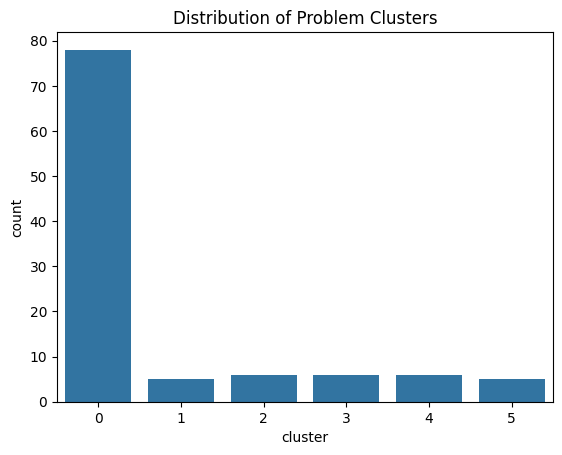

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="cluster", data=df_problems)

plt.title("Distribution of Problem Clusters")
plt.show()

# LLM Topic Labeling vs  LDA 

In [34]:
lda_topic_labels = {
    0: "Delivery & Arrival",
    1: "Ease of Setup",
    2: "Daily Use Satisfaction",
    3: "Kitchen & Appliance Products",
    4: "Build Quality",
    5: "Product Accuracy",
    6: "Furniture & Frames",
    7: "Mattress & Comfort",
    8: "Recommendation & Value",
    9: "Mixed Product Category"
}

In [33]:
lda_topics = {
0: ["absolutely love","perfectly","work perfectly","arrive time","buy"],
1: ["build easy","easy set","family love","set","easy"],
2: ["outstanding","daily routine","routine easy","product","easy thank"],
3: ["instabrew coffee","coffee maker","rainfall showerhead","aquaflow rainfall"],
4: ["excellent build","gift recipient","build quality","recipient love"],
5: ["exactly advertise","good purchase","purchase year","work exactly"],
6: ["turboblend pro","bed frame","frame queen","woodcraft bed"],
7: ["foam mattress","memory foam","floor lamp","glowlight floor"],
8: ["exceed expectation","highly recommend","great product"],
9: ["food processor","slicemaster food","cloudpillow set"]
}

In [35]:
from src.llm_tasks import label_topic

topic_labels = []

for topic_id, keywords in lda_topics.items():

    label = label_topic(keywords)

    topic_labels.append({
        "topic_id": topic_id,
        "keywords": ", ".join(keywords),
        "llm_label": label
    })

df_topic_labels = pd.DataFrame(topic_labels)

df_topic_labels

,topic_id,keywords,llm_label
0,0,"absolutely love, perfectly, work perfectly, ar...",Perfect purchase experience
1,1,"build easy, easy set, family love, set, easy",Easy setup loved
2,2,"outstanding, daily routine, routine easy, prod...",Effortless daily product
3,3,"instabrew coffee, coffee maker, rainfall showe...",Rainfall coffee maker
4,4,"excellent build, gift recipient, build quality...",Premium Gift Quality
5,5,"exactly advertise, good purchase, purchase yea...",Perfect as described
6,6,"turboblend pro, bed frame, frame queen, woodcr...",Premium Wooden Bed Frame
7,7,"foam mattress, memory foam, floor lamp, glowli...",Memory foam & lighting
8,8,"exceed expectation, highly recommend, great pr...",Exceeds expectations
9,9,"food processor, slicemaster food, cloudpillow set",Kitchen Appliances & Bedding


In [37]:
df_topic_labels[["topic_id","llm_label","keywords"]]

,topic_id,llm_label,keywords
0,0,Perfect purchase experience,"absolutely love, perfectly, work perfectly, ar..."
1,1,Easy setup loved,"build easy, easy set, family love, set, easy"
2,2,Effortless daily product,"outstanding, daily routine, routine easy, prod..."
3,3,Rainfall coffee maker,"instabrew coffee, coffee maker, rainfall showe..."
4,4,Premium Gift Quality,"excellent build, gift recipient, build quality..."
5,5,Perfect as described,"exactly advertise, good purchase, purchase yea..."
6,6,Premium Wooden Bed Frame,"turboblend pro, bed frame, frame queen, woodcr..."
7,7,Memory foam & lighting,"foam mattress, memory foam, floor lamp, glowli..."
8,8,Exceeds expectations,"exceed expectation, highly recommend, great pr..."
9,9,Kitchen Appliances & Bedding,"food processor, slicemaster food, cloudpillow set"


In [38]:
df_topic_labels = df_topic_labels.rename(columns={
    "topic_id":"Topic",
    "llm_label":"LLM Topic Label",
    "keywords":"Top Keywords"
})

df_topic_labels

,Topic,Top Keywords,LLM Topic Label
0,0,"absolutely love, perfectly, work perfectly, ar...",Perfect purchase experience
1,1,"build easy, easy set, family love, set, easy",Easy setup loved
2,2,"outstanding, daily routine, routine easy, prod...",Effortless daily product
3,3,"instabrew coffee, coffee maker, rainfall showe...",Rainfall coffee maker
4,4,"excellent build, gift recipient, build quality...",Premium Gift Quality
5,5,"exactly advertise, good purchase, purchase yea...",Perfect as described
6,6,"turboblend pro, bed frame, frame queen, woodcr...",Premium Wooden Bed Frame
7,7,"foam mattress, memory foam, floor lamp, glowli...",Memory foam & lighting
8,8,"exceed expectation, highly recommend, great pr...",Exceeds expectations
9,9,"food processor, slicemaster food, cloudpillow set",Kitchen Appliances & Bedding


In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_with_summaries.csv")

df = df.sample(300, random_state=42).reset_index(drop=True)

print(df.head())

   review_id   product_category                    product_name  \
0       1502        Living Room         SoundBar X200 Bluetooth   
1       2587        Living Room             SmartTV 55in 4K UHD   
2       2654           Bathroom    AquaFlow Rainfall Showerhead   
3       1056  Bedroom Furniture  DreamRest Memory Foam Mattress   
4        706  Bedroom Furniture        CloudPillow Set (2-pack)   

                                         review_text  star_rating review_date  \
0  Five stars. The SoundBar X200 Bluetooth is wel...            4  2023-07-26   
1  Absolutely love my SmartTV 55in 4K UHD! Works ...            4  2023-12-26   
2  The AquaFlow Rainfall Showerhead is easy to cl...            4  2024-09-12   
3  I was skeptical at first but the DreamRest Mem...            5  2023-10-17   
4  I was skeptical at first but the CloudPillow S...            4  2024-12-08   

   verified_purchase                                    text_for_topics  \
0               True  star soundbar

In [3]:
from transformers import pipeline

bert = pipeline("sentiment-analysis")

def bert_predict(text):
    result = bert(text[:512])[0]

    if result['label'] == "NEGATIVE":
        return "negative"
    else:
        return "positive"

df["bert_pred"] = df["review_text"].apply(bert_predict)

c:\Stellantis\HomeNestReviews_llm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
c:\Stellantis\HomeNestReviews_llm\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TA26012\.cache\huggingface\hub

NameError: name 'torch' is not defined